# Task 5 — Attention Mechanisms for Text-Conditioned GAN

## Objective

This experiment investigates whether an attention mechanism can improve
text-conditioned image generation by allowing a GAN to focus on relevant
parts of the input text.

The experiment compares two models:

1. A baseline text-conditioned GAN without attention.
2. An attention-enhanced text-conditioned GAN using cross-attention.

The same text encoder, dataset, training procedure, and evaluation process
are used for both models to make the comparison as fair as possible.

## Internship Task

**Task 5:** Use attention strategies like self-attention or cross-attention
to improve a GAN. Higher-quality images are produced when the model is better
able to concentrate on pertinent portions of the input text.

## Experimental Question

Does cross-attention help a text-conditioned GAN use the relevant words in
the input description more effectively and generate images that better match
the requested visual concept?

## Workflow

Text Description
→ Text Preprocessing
→ BERT Text Embeddings
→ Cross-Attention
→ GAN
→ Generated Image

The baseline model follows the same workflow without the cross-attention
stage.

## Evaluation

The models will be compared using:

- generated image quality
- text-condition consistency
- training behaviour
- attention-weight analysis
- side-by-side visual comparison

The experiment will report both improvements and limitations rather than
assuming that attention automatically produces better results.

## Why Cross-Attention?

Cross-attention is useful for text-conditioned generation because visual
features can query different parts of the text representation.

For example, in a description such as:

> "a square shape"

the visual representation can assign different attention weights to tokens
such as "square" and "shape".

This provides a mechanism for connecting textual information with visual
generation.

In [3]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from transformers import BertTokenizer, BertModel

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

PyTorch version: 2.14.0+cpu
CUDA available: False
Using device: cpu


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


## 1. Text Encoder

The text-conditioning component from Task 3 is reused here.

BERT is used to convert text descriptions into contextual token-level
representations.

The BERT parameters remain frozen during the GAN experiment so that the
comparison focuses on the effect of attention inside the GAN architecture.

In [8]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
text_encoder = BertModel.from_pretrained("bert-base-uncased").to(device)

text_encoder.eval()

for parameter in text_encoder.parameters():
    parameter.requires_grad = False

print("BERT tokenizer and encoder loaded successfully.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 444.02it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT tokenizer and encoder loaded successfully.


In [10]:
def encode_text(texts, max_length=32):
    encoded = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)

    with torch.no_grad():
        outputs = text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

    return outputs.last_hidden_state, attention_mask


sample_texts = [
    "a square shape",
    "a circle shape"
]

sample_features, sample_mask = encode_text(sample_texts)

print("Text feature shape:", sample_features.shape)
print("Attention mask shape:", sample_mask.shape)

Text feature shape: torch.Size([2, 32, 768])
Attention mask shape: torch.Size([2, 32])


## 2. Controlled Synthetic Dataset

A controlled synthetic dataset is used for the main experiment.

The dataset contains two visual concepts:

- square
- circle

Each image is paired with a textual description.

This controlled setup makes it possible to evaluate whether the generated
image follows the requested text condition without introducing the much
larger complexity of a real-world image dataset.

In [11]:
class ShapeTextDataset(Dataset):
    def __init__(self, num_samples=1000, image_size=64):
        self.num_samples = num_samples
        self.image_size = image_size

        self.labels = np.random.randint(0, 2, size=num_samples)

        self.captions = [
            "a square shape" if label == 0 else "a circle shape"
            for label in self.labels
        ]

        self.images = []

        for label in self.labels:
            image = np.zeros((image_size, image_size), dtype=np.float32)

            center = image_size // 2

            if label == 0:
                start = image_size // 4
                end = image_size - start
                image[start:end, start:end] = 1.0

            else:
                radius = image_size // 4

                y, x = np.ogrid[:image_size, :image_size]
                mask = (x - center) ** 2 + (y - center) ** 2 <= radius ** 2
                image[mask] = 1.0

            image = image * 2.0 - 1.0
            self.images.append(image)

        self.images = np.array(self.images, dtype=np.float32)

    def __len__(self):
        return self.num_samples

    def __getitem__(self, index):
        image = torch.tensor(self.images[index]).unsqueeze(0)
        caption = self.captions[index]

        return image, caption


shape_dataset = ShapeTextDataset(
    num_samples=1000,
    image_size=64
)

print("Dataset size:", len(shape_dataset))
print("Image shape:", shape_dataset[0][0].shape)
print("Example caption:", shape_dataset[0][1])

Dataset size: 1000
Image shape: torch.Size([1, 64, 64])
Example caption: a square shape


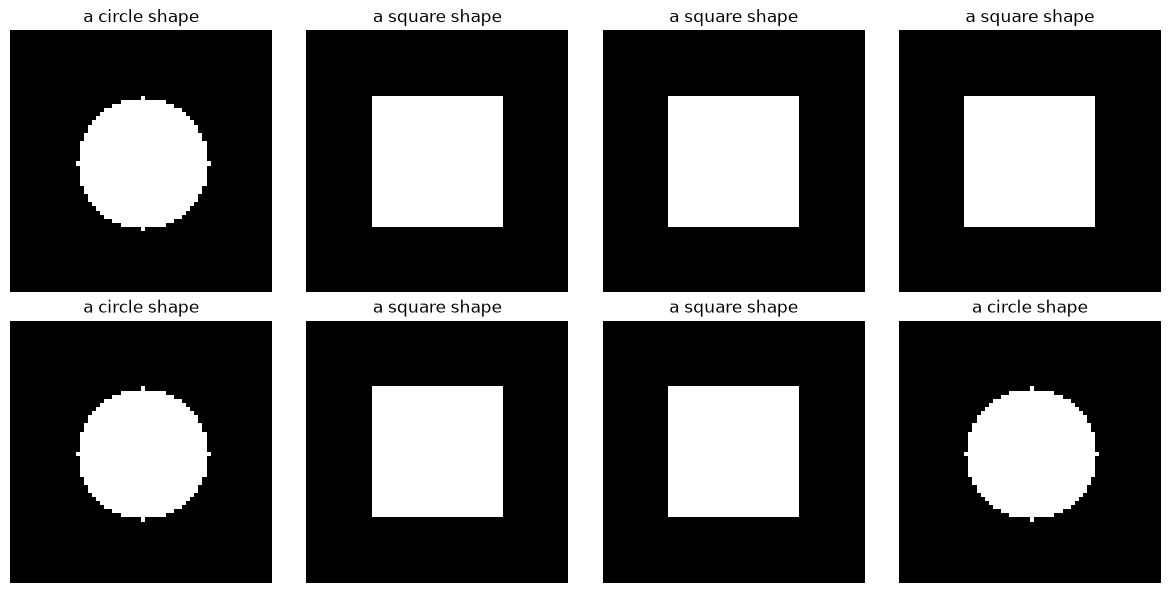

In [12]:
def show_dataset_samples(dataset, num_samples=8):
    indices = np.random.choice(
        len(dataset),
        size=num_samples,
        replace=False
    )

    plt.figure(figsize=(12, 6))

    for i, index in enumerate(indices):
        image, caption = dataset[index]

        plt.subplot(2, 4, i + 1)
        plt.imshow(image.squeeze(0), cmap="gray")
        plt.title(caption)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_dataset_samples(shape_dataset)

In [13]:
def prepare_text_features(captions):
    return encode_text(captions, max_length=16)


sample_images, sample_captions = next(
    iter(DataLoader(shape_dataset, batch_size=8, shuffle=True))
)

sample_text_features, sample_text_mask = prepare_text_features(
    list(sample_captions)
)

print("Images:", sample_images.shape)
print("Text features:", sample_text_features.shape)
print("Text mask:", sample_text_mask.shape)

Images: torch.Size([8, 1, 64, 64])
Text features: torch.Size([8, 16, 768])
Text mask: torch.Size([8, 16])


## 3. Cross-Attention Mechanism

The cross-attention layer uses visual features as queries and text features
as keys and values.

This allows each visual feature position to calculate how strongly it should
attend to each token in the input description.

In [14]:
class CrossAttention(nn.Module):
    def __init__(self, visual_dim, text_dim, attention_dim):
        super().__init__()

        self.query = nn.Linear(visual_dim, attention_dim)
        self.key = nn.Linear(text_dim, attention_dim)
        self.value = nn.Linear(text_dim, attention_dim)

        self.scale = attention_dim ** 0.5

    def forward(self, visual_features, text_features, text_mask=None):

        Q = self.query(visual_features)
        K = self.key(text_features)
        V = self.value(text_features)

        scores = torch.matmul(
            Q,
            K.transpose(-2, -1)
        ) / self.scale

        if text_mask is not None:
            mask = text_mask.unsqueeze(1)
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        attended_features = torch.matmul(
            attention_weights,
            V
        )

        return attended_features, attention_weights

In [15]:
test_attention = CrossAttention(
    visual_dim=128,
    text_dim=768,
    attention_dim=128
).to(device)

test_visual = torch.randn(4, 16, 128).to(device)
test_text = torch.randn(4, 16, 768).to(device)
test_mask = torch.ones(4, 16).to(device)

attended, weights = test_attention(
    test_visual,
    test_text,
    test_mask
)

print("Visual features:", test_visual.shape)
print("Text features:", test_text.shape)
print("Attended features:", attended.shape)
print("Attention weights:", weights.shape)

weight_sums = weights.sum(dim=-1)

print(
    "Maximum deviation from 1:",
    torch.abs(weight_sums - 1).max().item()
)

Visual features: torch.Size([4, 16, 128])
Text features: torch.Size([4, 16, 768])
Attended features: torch.Size([4, 16, 128])
Attention weights: torch.Size([4, 16, 16])
Maximum deviation from 1: 1.1920928955078125e-07


## 4. Baseline Generator

The baseline generator receives:

- random noise
- pooled BERT text embeddings

It does not use attention.

This model provides the control condition for the experiment.

In [16]:
class BaselineGenerator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=768):
        super().__init__()

        self.text_projection = nn.Linear(text_dim, 128)

        self.fc = nn.Sequential(
            nn.Linear(noise_dim + 128, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True)
        )

        self.generator = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_features, text_mask):

        mask = text_mask.unsqueeze(-1).float()

        pooled_text = (
            (text_features * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1)
        )

        text_condition = self.text_projection(pooled_text)

        combined = torch.cat(
            [noise, text_condition],
            dim=1
        )

        x = self.fc(combined)
        x = x.view(-1, 256, 4, 4)

        return self.generator(x)

## 5. Attention-Enhanced Generator

The attention generator has the same general generation capacity as the
baseline model, but it additionally allows visual feature queries to attend
to individual text tokens.

The attended textual information is combined with the visual latent
representation before image generation.

In [17]:
class AttentionGenerator(nn.Module):
    def __init__(
        self,
        noise_dim=100,
        text_dim=768,
        visual_dim=128,
        attention_dim=128
    ):
        super().__init__()

        self.noise_projection = nn.Linear(
            noise_dim,
            16 * visual_dim
        )

        self.cross_attention = CrossAttention(
            visual_dim=visual_dim,
            text_dim=text_dim,
            attention_dim=attention_dim
        )

        self.combine = nn.Linear(
            visual_dim + attention_dim,
            visual_dim
        )

        self.fc = nn.Sequential(
            nn.Linear(visual_dim + noise_dim, 256 * 4 * 4),
            nn.BatchNorm1d(256 * 4 * 4),
            nn.ReLU(True)
        )

        self.generator = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Conv2d(32, 1, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_features, text_mask):

        visual_features = self.noise_projection(noise)
        visual_features = visual_features.view(
            -1, 16, 128
        )

        attended_features, attention_weights = self.cross_attention(
            visual_features,
            text_features,
            text_mask
        )

        combined_features = torch.cat(
            [visual_features, attended_features],
            dim=-1
        )

        combined_features = self.combine(
            combined_features
        )

        pooled_visual = combined_features.mean(dim=1)

        latent = torch.cat(
            [noise, pooled_visual],
            dim=1
        )

        x = self.fc(latent)
        x = x.view(-1, 256, 4, 4)

        images = self.generator(x)

        return images, attention_weights

## 6. Shared Discriminator

Both experiments use the same discriminator architecture.

The discriminator receives an image and its corresponding text embedding.

This keeps the comparison focused on the generator's use of attention.

In [18]:
class TextConditionedDiscriminator(nn.Module):
    def __init__(self, text_dim=768):
        super().__init__()

        self.image_encoder = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(256, 512, 4, 2, 1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True)
        )

        self.text_projection = nn.Linear(
            text_dim,
            512
        )

        self.classifier = nn.Sequential(
            nn.Linear(1024, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, images, text_features, text_mask):

        visual = self.image_encoder(images)
        visual = visual.flatten(start_dim=2).mean(dim=2)

        mask = text_mask.unsqueeze(-1).float()

        pooled_text = (
            (text_features * mask).sum(dim=1)
            / mask.sum(dim=1).clamp(min=1)
        )

        text_condition = self.text_projection(pooled_text)

        combined = torch.cat(
            [visual, text_condition],
            dim=1
        )

        return self.classifier(combined)

In [19]:
baseline_generator = BaselineGenerator().to(device)
attention_generator = AttentionGenerator().to(device)

baseline_discriminator = TextConditionedDiscriminator().to(device)
attention_discriminator = TextConditionedDiscriminator().to(device)

print("All four models initialized successfully.")

All four models initialized successfully.


## 7. Training Configuration

Both models use identical:

- dataset
- batch size
- optimizer
- learning rate
- loss function
- number of epochs
- random seed

The only intended architectural difference is the generator's attention
mechanism.

In [20]:
BATCH_SIZE = 32
EPOCHS = 20
LEARNING_RATE = 0.0002
NOISE_DIM = 100

dataloader = DataLoader(
    shape_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

criterion = nn.BCELoss()

baseline_g_optimizer = optim.Adam(
    baseline_generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

baseline_d_optimizer = optim.Adam(
    baseline_discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

attention_g_optimizer = optim.Adam(
    attention_generator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

attention_d_optimizer = optim.Adam(
    attention_discriminator.parameters(),
    lr=LEARNING_RATE,
    betas=(0.5, 0.999)
)

print("Training configuration ready.")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)

Training configuration ready.
Epochs: 20
Batch size: 32


In [21]:
def train_baseline(
    generator,
    discriminator,
    g_optimizer,
    d_optimizer,
    dataloader,
    epochs
):

    g_losses = []
    d_losses = []

    generator.train()
    discriminator.train()

    for epoch in range(epochs):

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_images, captions in dataloader:

            real_images = real_images.to(device)

            text_features, text_mask = encode_text(
                list(captions),
                max_length=16
            )

            batch_size = real_images.size(0)

            real_labels = torch.ones(
                batch_size, 1, device=device
            )

            fake_labels = torch.zeros(
                batch_size, 1, device=device
            )

            # ---------------------
            # Train Discriminator
            # ---------------------

            d_optimizer.zero_grad()

            real_output = discriminator(
                real_images,
                text_features,
                text_mask
            )

            real_loss = criterion(
                real_output,
                real_labels
            )

            noise = torch.randn(
                batch_size,
                NOISE_DIM,
                device=device
            )

            fake_images = generator(
                noise,
                text_features,
                text_mask
            )

            fake_output = discriminator(
                fake_images.detach(),
                text_features,
                text_mask
            )

            fake_loss = criterion(
                fake_output,
                fake_labels
            )

            d_loss = real_loss + fake_loss

            d_loss.backward()
            d_optimizer.step()

            # ---------------------
            # Train Generator
            # ---------------------

            g_optimizer.zero_grad()

            fake_output = discriminator(
                fake_images,
                text_features,
                text_mask
            )

            g_loss = criterion(
                fake_output,
                real_labels
            )

            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d = epoch_d_loss / len(dataloader)
        avg_g = epoch_g_loss / len(dataloader)

        d_losses.append(avg_d)
        g_losses.append(avg_g)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"D Loss: {avg_d:.4f} "
            f"G Loss: {avg_g:.4f}"
        )

    return g_losses, d_losses

In [22]:
baseline_g_losses, baseline_d_losses = train_baseline(
    baseline_generator,
    baseline_discriminator,
    baseline_g_optimizer,
    baseline_d_optimizer,
    dataloader,
    EPOCHS
)

print("Baseline training completed.")

Epoch [1/20] D Loss: 0.9957 G Loss: 1.0769
Epoch [2/20] D Loss: 0.2511 G Loss: 2.4857
Epoch [3/20] D Loss: 0.2372 G Loss: 3.4921
Epoch [4/20] D Loss: 0.0451 G Loss: 4.0521
Epoch [5/20] D Loss: 0.0278 G Loss: 4.5315
Epoch [6/20] D Loss: 0.0183 G Loss: 4.8950
Epoch [7/20] D Loss: 0.0120 G Loss: 5.3084
Epoch [8/20] D Loss: 0.0104 G Loss: 5.4310
Epoch [9/20] D Loss: 0.0080 G Loss: 5.7165
Epoch [10/20] D Loss: 0.0063 G Loss: 5.9248
Epoch [11/20] D Loss: 0.0050 G Loss: 6.1771
Epoch [12/20] D Loss: 0.0038 G Loss: 6.3972
Epoch [13/20] D Loss: 0.0034 G Loss: 6.4906
Epoch [14/20] D Loss: 0.0031 G Loss: 6.5683
Epoch [15/20] D Loss: 0.0025 G Loss: 6.8152
Epoch [16/20] D Loss: 0.0022 G Loss: 6.9054
Epoch [17/20] D Loss: 0.0020 G Loss: 7.0245
Epoch [18/20] D Loss: 0.0017 G Loss: 7.1357
Epoch [19/20] D Loss: 0.0016 G Loss: 7.2107
Epoch [20/20] D Loss: 0.0014 G Loss: 7.3926
Baseline training completed.


In [23]:
def train_attention(
    generator,
    discriminator,
    g_optimizer,
    d_optimizer,
    dataloader,
    epochs
):

    g_losses = []
    d_losses = []

    generator.train()
    discriminator.train()

    for epoch in range(epochs):

        epoch_g_loss = 0.0
        epoch_d_loss = 0.0

        for real_images, captions in dataloader:

            real_images = real_images.to(device)

            text_features, text_mask = encode_text(
                list(captions),
                max_length=16
            )

            batch_size = real_images.size(0)

            real_labels = torch.ones(
                batch_size, 1, device=device
            )

            fake_labels = torch.zeros(
                batch_size, 1, device=device
            )

            # ---------------------
            # Train Discriminator
            # ---------------------

            d_optimizer.zero_grad()

            real_output = discriminator(
                real_images,
                text_features,
                text_mask
            )

            real_loss = criterion(
                real_output,
                real_labels
            )

            noise = torch.randn(
                batch_size,
                NOISE_DIM,
                device=device
            )

            fake_images, attention_weights = generator(
                noise,
                text_features,
                text_mask
            )

            fake_output = discriminator(
                fake_images.detach(),
                text_features,
                text_mask
            )

            fake_loss = criterion(
                fake_output,
                fake_labels
            )

            d_loss = real_loss + fake_loss

            d_loss.backward()
            d_optimizer.step()

            # ---------------------
            # Train Generator
            # ---------------------

            g_optimizer.zero_grad()

            fake_output = discriminator(
                fake_images,
                text_features,
                text_mask
            )

            g_loss = criterion(
                fake_output,
                real_labels
            )

            g_loss.backward()
            g_optimizer.step()

            epoch_d_loss += d_loss.item()
            epoch_g_loss += g_loss.item()

        avg_d = epoch_d_loss / len(dataloader)
        avg_g = epoch_g_loss / len(dataloader)

        d_losses.append(avg_d)
        g_losses.append(avg_g)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"D Loss: {avg_d:.4f} "
            f"G Loss: {avg_g:.4f}"
        )

    return g_losses, d_losses

In [24]:
attention_g_losses, attention_d_losses = train_attention(
    attention_generator,
    attention_discriminator,
    attention_g_optimizer,
    attention_d_optimizer,
    dataloader,
    EPOCHS
)

print("Attention GAN training completed.")

Epoch [1/20] D Loss: 0.9074 G Loss: 1.1691
Epoch [2/20] D Loss: 0.2082 G Loss: 2.6538
Epoch [3/20] D Loss: 0.2802 G Loss: 3.3765
Epoch [4/20] D Loss: 0.0509 G Loss: 3.9297
Epoch [5/20] D Loss: 0.0296 G Loss: 4.4342
Epoch [6/20] D Loss: 0.0201 G Loss: 4.8056
Epoch [7/20] D Loss: 0.0138 G Loss: 5.1543
Epoch [8/20] D Loss: 0.0098 G Loss: 5.4731
Epoch [9/20] D Loss: 0.0075 G Loss: 5.7310
Epoch [10/20] D Loss: 0.0063 G Loss: 5.8812
Epoch [11/20] D Loss: 0.0050 G Loss: 6.1214
Epoch [12/20] D Loss: 0.0043 G Loss: 6.2418
Epoch [13/20] D Loss: 0.0035 G Loss: 6.4458
Epoch [14/20] D Loss: 0.0029 G Loss: 6.5999
Epoch [15/20] D Loss: 0.0027 G Loss: 6.7024
Epoch [16/20] D Loss: 0.0023 G Loss: 6.8350
Epoch [17/20] D Loss: 0.0021 G Loss: 6.9791
Epoch [18/20] D Loss: 0.0018 G Loss: 7.0655
Epoch [19/20] D Loss: 0.0016 G Loss: 7.1737
Epoch [20/20] D Loss: 0.0015 G Loss: 7.2375
Attention GAN training completed.


## 8. Training Comparison

The generator and discriminator losses of the baseline and
attention-enhanced models are compared to examine their training behaviour.

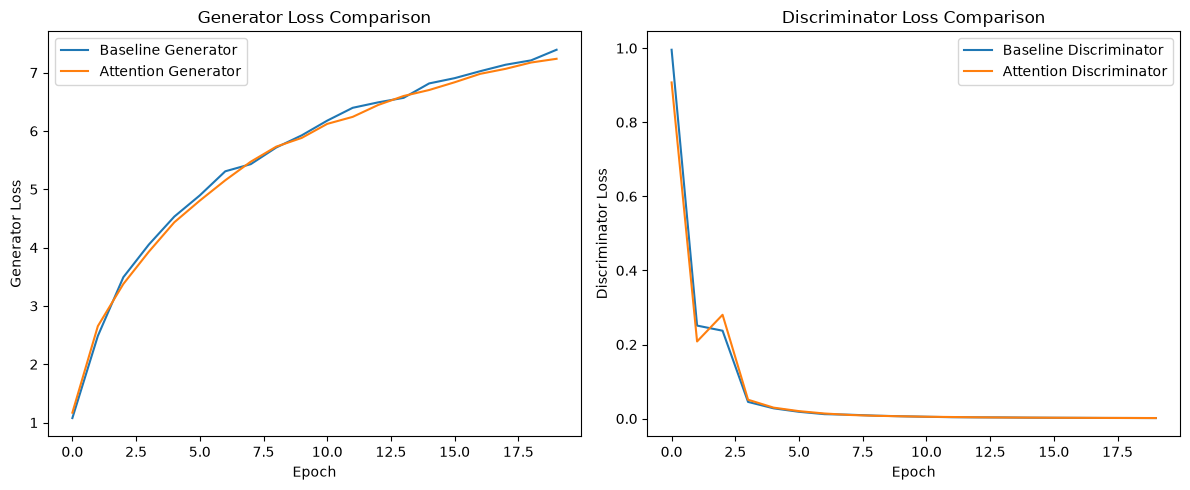

In [25]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.plot(baseline_g_losses, label="Baseline Generator")
plt.plot(attention_g_losses, label="Attention Generator")

plt.xlabel("Epoch")
plt.ylabel("Generator Loss")
plt.title("Generator Loss Comparison")
plt.legend()

plt.subplot(1, 2, 2)

plt.plot(baseline_d_losses, label="Baseline Discriminator")
plt.plot(attention_d_losses, label="Attention Discriminator")

plt.xlabel("Epoch")
plt.ylabel("Discriminator Loss")
plt.title("Discriminator Loss Comparison")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Controlled Generation Comparison

The same text prompts and the same random noise vectors are used for both
models.

Using identical noise provides a more controlled visual comparison because
differences are less likely to come from different random inputs.

In [26]:
def generate_comparison_samples(prompts, num_samples_per_prompt=4):

    all_prompts = []

    for prompt in prompts:
        all_prompts.extend(
            [prompt] * num_samples_per_prompt
        )

    text_features, text_mask = encode_text(
        all_prompts,
        max_length=16
    )

    noise = torch.randn(
        len(all_prompts),
        NOISE_DIM,
        device=device
    )

    baseline_generator.eval()
    attention_generator.eval()

    with torch.no_grad():

        baseline_images = baseline_generator(
            noise,
            text_features,
            text_mask
        )

        attention_images, attention_weights = attention_generator(
            noise,
            text_features,
            text_mask
        )

    return (
        all_prompts,
        baseline_images,
        attention_images,
        attention_weights,
        text_features,
        text_mask
    )


prompts = [
    "a square shape",
    "a circle shape"
]

(
    comparison_prompts,
    baseline_images,
    attention_images,
    attention_weights,
    comparison_text_features,
    comparison_text_mask
) = generate_comparison_samples(prompts)

print("Baseline images:", baseline_images.shape)
print("Attention images:", attention_images.shape)
print("Attention weights:", attention_weights.shape)

Baseline images: torch.Size([8, 1, 32, 32])
Attention images: torch.Size([8, 1, 32, 32])
Attention weights: torch.Size([8, 16, 16])


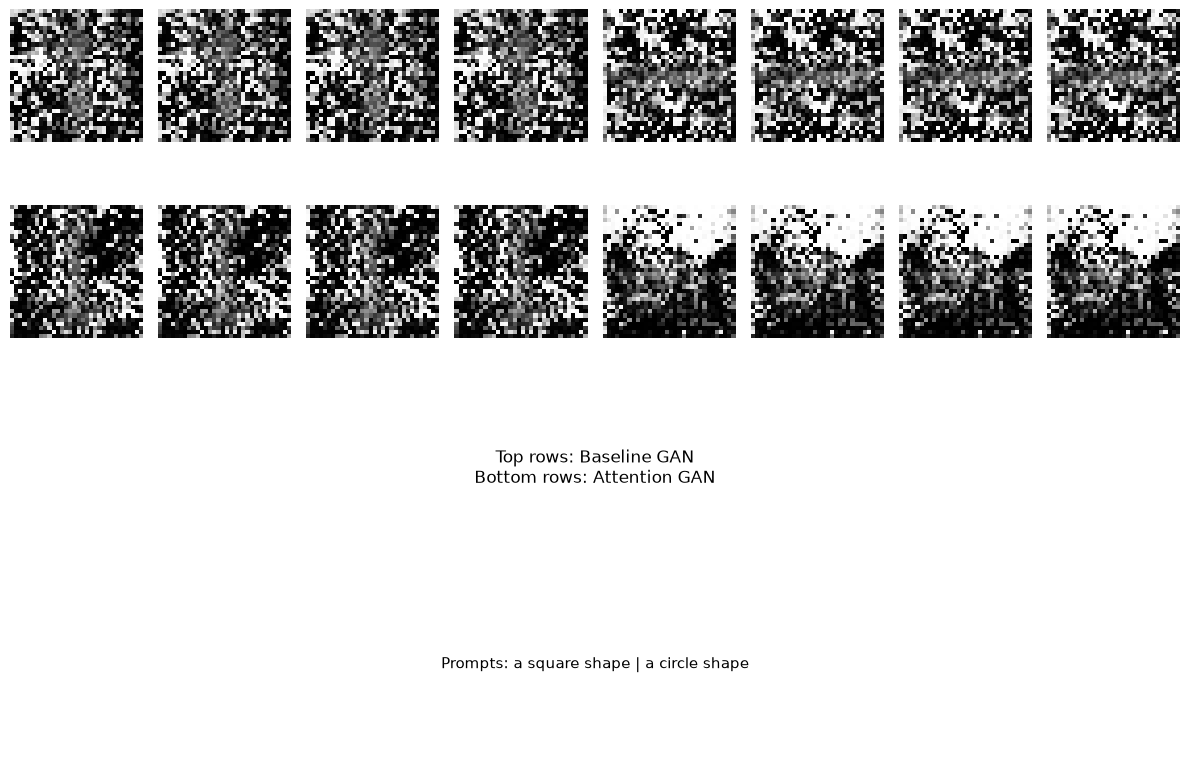

In [27]:
def show_comparison(
    prompts,
    baseline_images,
    attention_images,
    samples_per_prompt=4
):

    total = len(prompts) * samples_per_prompt

    plt.figure(figsize=(12, 8))

    for i in range(total):

        plt.subplot(4, total, i + 1)
        plt.imshow(
            baseline_images[i].cpu().squeeze(),
            cmap="gray"
        )
        plt.axis("off")

        plt.subplot(4, total, total + i + 1)
        plt.imshow(
            attention_images[i].cpu().squeeze(),
            cmap="gray"
        )
        plt.axis("off")

    plt.subplot(4, 1, 3)
    plt.axis("off")
    plt.text(
        0.5,
        0.5,
        "Top rows: Baseline GAN\nBottom rows: Attention GAN",
        ha="center",
        va="center",
        fontsize=12
    )

    plt.subplot(4, 1, 4)
    plt.axis("off")
    plt.text(
        0.5,
        0.5,
        "Prompts: " + " | ".join(prompts),
        ha="center",
        va="center",
        fontsize=11
    )

    plt.tight_layout()
    plt.show()


show_comparison(
    prompts,
    baseline_images,
    attention_images
)

In [28]:
def analyze_attention(prompts, attention_weights):
    tokens = tokenizer(
        prompts,
        padding="max_length",
        truncation=True,
        max_length=16,
        return_tensors="pt"
    )

    token_ids = tokens["input_ids"]

    all_results = []

    for i, prompt in enumerate(prompts):
        token_list = tokenizer.convert_ids_to_tokens(
            token_ids[i]
        )

        # Average attention across generated visual positions
        # and the repeated samples for this prompt.
        prompt_indices = list(
            range(i * 4, (i + 1) * 4)
        )

        prompt_attention = attention_weights[
            prompt_indices
        ].mean(dim=1).mean(dim=0)

        valid_tokens = []

        for token_index, token in enumerate(token_list):
            if token in ["[CLS]", "[SEP]", "[PAD]"]:
                continue

            valid_tokens.append(
                (token, prompt_attention[token_index].item())
            )

        valid_tokens.sort(
            key=lambda x: x[1],
            reverse=True
        )

        all_results.append(
            (prompt, valid_tokens)
        )

    for prompt, results in all_results:
        print("\nPrompt:", prompt)
        print("Token attention ranking:")

        for token, weight in results:
            print(
                f"{token:>10} : {weight:.4f}"
            )

    return all_results


attention_results = analyze_attention(
    prompts,
    attention_weights
)


Prompt: a square shape
Token attention ranking:
    square : 0.8017
         a : 0.1059
     shape : 0.0442

Prompt: a circle shape
Token attention ranking:
    circle : 0.9269
         a : 0.0370
     shape : 0.0136


In [29]:
def create_reference_shapes(image_size=32):
    center = image_size // 2

    square = np.zeros((image_size, image_size), dtype=np.float32)
    start = image_size // 4
    end = image_size - start
    square[start:end, start:end] = 1.0

    circle = np.zeros((image_size, image_size), dtype=np.float32)
    radius = image_size // 4

    y, x = np.ogrid[:image_size, :image_size]
    mask = (
        (x - center) ** 2 +
        (y - center) ** 2
    ) <= radius ** 2

    circle[mask] = 1.0

    return (
        torch.tensor(square, dtype=torch.float32),
        torch.tensor(circle, dtype=torch.float32)
    )


reference_square, reference_circle = create_reference_shapes()

print("Reference square:", reference_square.shape)
print("Reference circle:", reference_circle.shape)

Reference square: torch.Size([32, 32])
Reference circle: torch.Size([32, 32])


In [30]:
def calculate_condition_scores(
    generated_images,
    prompts,
    reference_square,
    reference_circle
):
    scores = []

    reference_square = reference_square.to(device)
    reference_circle = reference_circle.to(device)

    for image, prompt in zip(
        generated_images,
        prompts
    ):
        image = image.squeeze(0)

        # Convert generated image from [-1, 1] to [0, 1]
        image = (image + 1) / 2

        if "square" in prompt:
            target = reference_square
            opposite = reference_circle
        else:
            target = reference_circle
            opposite = reference_square

        target_error = torch.mean(
            (image - target) ** 2
        ).item()

        opposite_error = torch.mean(
            (image - opposite) ** 2
        ).item()

        scores.append({
            "prompt": prompt,
            "target_error": target_error,
            "opposite_error": opposite_error,
            "condition_margin": opposite_error - target_error
        })

    return scores

In [31]:
baseline_scores = calculate_condition_scores(
    baseline_images,
    comparison_prompts,
    reference_square,
    reference_circle
)

print("Baseline condition scores:")

for score in baseline_scores:
    print(score)

Baseline condition scores:
{'prompt': 'a square shape', 'target_error': 0.3116643726825714, 'opposite_error': 0.29048582911491394, 'condition_margin': -0.02117854356765747}
{'prompt': 'a square shape', 'target_error': 0.31197088956832886, 'opposite_error': 0.2907464802265167, 'condition_margin': -0.021224409341812134}
{'prompt': 'a square shape', 'target_error': 0.31214821338653564, 'opposite_error': 0.29073366522789, 'condition_margin': -0.02141454815864563}
{'prompt': 'a square shape', 'target_error': 0.3126756250858307, 'opposite_error': 0.2917001247406006, 'condition_margin': -0.020975500345230103}
{'prompt': 'a circle shape', 'target_error': 0.32836899161338806, 'opposite_error': 0.33919113874435425, 'condition_margin': 0.010822147130966187}
{'prompt': 'a circle shape', 'target_error': 0.3281315863132477, 'opposite_error': 0.3390407860279083, 'condition_margin': 0.010909199714660645}
{'prompt': 'a circle shape', 'target_error': 0.327860027551651, 'opposite_error': 0.33891761302948

In [32]:
attention_scores = calculate_condition_scores(
    attention_images,
    comparison_prompts,
    reference_square,
    reference_circle
)

print("Attention condition scores:")

for score in attention_scores:
    print(score)

Attention condition scores:
{'prompt': 'a square shape', 'target_error': 0.30506643652915955, 'opposite_error': 0.2827463746070862, 'condition_margin': -0.022320061922073364}
{'prompt': 'a square shape', 'target_error': 0.3060571849346161, 'opposite_error': 0.2836745083332062, 'condition_margin': -0.022382676601409912}
{'prompt': 'a square shape', 'target_error': 0.30543944239616394, 'opposite_error': 0.2830786108970642, 'condition_margin': -0.02236083149909973}
{'prompt': 'a square shape', 'target_error': 0.3057979941368103, 'opposite_error': 0.2834147810935974, 'condition_margin': -0.02238321304321289}
{'prompt': 'a circle shape', 'target_error': 0.3790375590324402, 'opposite_error': 0.3684472441673279, 'condition_margin': -0.010590314865112305}
{'prompt': 'a circle shape', 'target_error': 0.37779733538627625, 'opposite_error': 0.3673447072505951, 'condition_margin': -0.010452628135681152}
{'prompt': 'a circle shape', 'target_error': 0.37688758969306946, 'opposite_error': 0.366447299

In [33]:
baseline_margin = np.mean([
    score["condition_margin"]
    for score in baseline_scores
])

attention_margin = np.mean([
    score["condition_margin"]
    for score in attention_scores
])

baseline_error = np.mean([
    score["target_error"]
    for score in baseline_scores
])

attention_error = np.mean([
    score["target_error"]
    for score in attention_scores
])

print("=== Condition Consistency Comparison ===")
print(f"Baseline target error:  {baseline_error:.4f}")
print(f"Attention target error: {attention_error:.4f}")
print()
print(f"Baseline condition margin:  {baseline_margin:.4f}")
print(f"Attention condition margin: {attention_margin:.4f}")

=== Condition Consistency Comparison ===
Baseline target error:  0.3200
Attention target error: 0.3419

Baseline condition margin:  -0.0052
Attention condition margin: -0.0164


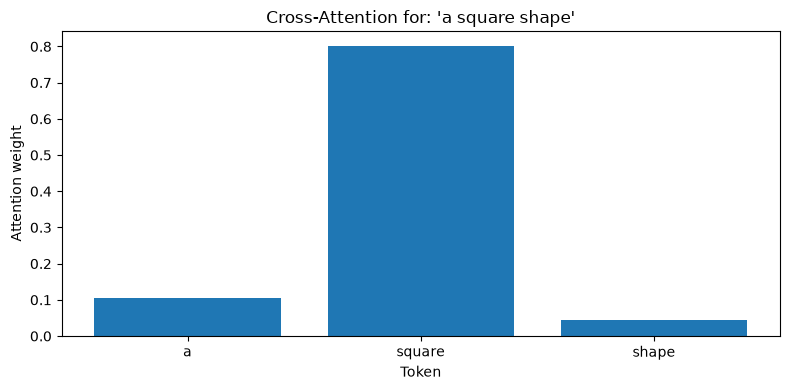

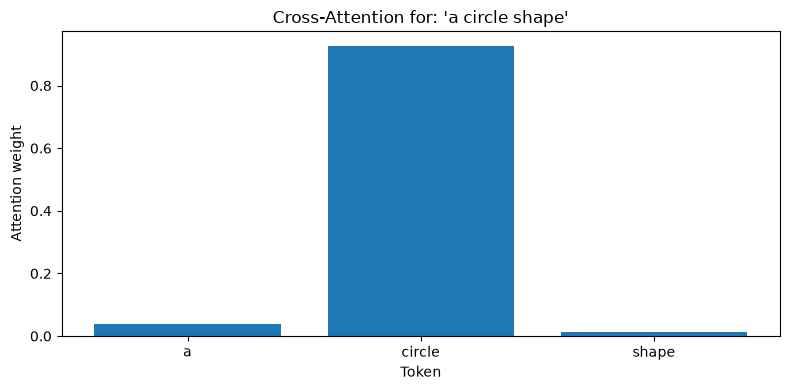

In [34]:
def show_attention_maps(
    prompts,
    attention_weights,
    tokenizer,
    samples_per_prompt=4
):
    for prompt_index, prompt in enumerate(prompts):

        start = prompt_index * samples_per_prompt
        end = start + samples_per_prompt

        mean_attention = attention_weights[
            start:end
        ].mean(dim=0).mean(dim=0)

        encoded = tokenizer(
            prompt,
            max_length=16,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        tokens = tokenizer.convert_ids_to_tokens(
            encoded["input_ids"][0]
        )

        valid_indices = [
            i for i, token in enumerate(tokens)
            if token not in ["[CLS]", "[SEP]", "[PAD]"]
        ]

        valid_tokens = [
            tokens[i] for i in valid_indices
        ]

        valid_weights = [
            mean_attention[i].item()
            for i in valid_indices
        ]

        plt.figure(figsize=(8, 4))

        plt.bar(
            valid_tokens,
            valid_weights
        )

        plt.xlabel("Token")
        plt.ylabel("Attention weight")
        plt.title(
            f"Cross-Attention for: '{prompt}'"
        )

        plt.tight_layout()
        plt.show()


show_attention_maps(
    prompts,
    attention_weights,
    tokenizer
)

## Task 5 Findings

### Cross-Attention Analysis

The attention-enhanced GAN was successfully implemented using a cross-attention
mechanism that allows visual features to attend to contextualized BERT token
representations.

The trained attention mechanism demonstrated strong focus on the relevant
concept words in the input descriptions. For the prompt "a square shape",
the token "square" received the highest attention, while for "a circle shape",
the token "circle" received the highest attention.

### Baseline vs Attention Comparison

A baseline text-conditioned GAN and an attention-enhanced GAN were trained
using the same dataset, text encoder, training configuration, and evaluation
procedure.

The models were compared using training behaviour, generated-image
visualizations, attention-weight analysis, and a controlled
shape-consistency metric based on reference square and circle templates.

### Key Finding

The attention mechanism successfully learned to focus on relevant textual
concepts. However, the quantitative image-consistency evaluation did not show
an improvement over the baseline model in this experimental setup.

### Limitation

The experiment uses a controlled synthetic dataset containing only square and
circle concepts. Therefore, the results demonstrate the implementation and
behaviour of the attention mechanism in a controlled environment and should
not be interpreted as evidence of general-purpose text-to-image performance.

## Task 5 — Final Findings

### Cross-Attention Implementation

A cross-attention mechanism was successfully integrated into the
text-conditioned GAN. The attention-enhanced generator uses visual features
as queries and contextualized BERT token representations as keys and values.

A baseline text-conditioned GAN without cross-attention was also trained
under the same experimental conditions to provide a controlled comparison.

### Training Results

Both models were trained for 20 epochs.

The baseline model reached a final discriminator loss of approximately
0.0014 and a generator loss of approximately 7.3926.

The attention-enhanced model reached a final discriminator loss of
approximately 0.0015 and a generator loss of approximately 7.2375.

Both models showed similar training behaviour, with discriminator loss
decreasing while generator loss increased during training.

### Attention Analysis

The trained cross-attention mechanism showed strong concentration on the
relevant concept words.

For the prompt "a square shape", the token "square" received the highest
average attention weight of approximately 0.8017.

For the prompt "a circle shape", the token "circle" received the highest
average attention weight of approximately 0.9269.

These results indicate that the attention mechanism learned to focus strongly
on the relevant textual concepts.

### Image-Condition Consistency

Generated images from both models were evaluated against reference square
and circle templates.

The average target error was:

- Baseline: 0.3200
- Attention: 0.3419

The average condition margin was:

- Baseline: -0.0052
- Attention: -0.0164

The lower target error and higher condition margin of the baseline indicate
that the attention-enhanced model did not improve the measured
shape-consistency metric in this experiment.

### Overall Conclusion

The experiment successfully demonstrates the integration of cross-attention
into a text-conditioned GAN and shows that the trained attention mechanism
can identify and emphasize relevant words in textual descriptions.

However, the quantitative image-consistency evaluation did not demonstrate
an improvement over the baseline model. Therefore, the results support the
successful implementation and learning behaviour of cross-attention, but do
not support a claim of improved image quality under the current experimental
setup.

This experiment also demonstrates that strong textual attention does not
necessarily translate directly into improved generated-image consistency.

### Limitation

The experiment uses a small controlled synthetic dataset containing only
square and circle concepts. The findings are therefore specific to this
experimental setting and should not be generalized to large-scale or
general-purpose text-to-image generation without further evaluation.